<a href="https://colab.research.google.com/github/SafiBD/machine-learning/blob/main/WE_Working_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/Python for ML/WE_main.xlsx')

In [ ]:
df.head()
df.info()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30078 entries, 0 to 30077
Data columns (total 38 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   Respondent's current age                                            30078 non-null  int64  
 1   Age in 5-year groups                                                30078 non-null  object 
 2   Division                                                            30078 non-null  object 
 3   Type of place of residence                                          30078 non-null  object 
 4   Division.1                                                          30078 non-null  object 
 5   Type of place of residence.1                                        30078 non-null  object 
 6   Religion                                                            30078 non-null  object 
 7   Education in 

Index(['Respondent's current age', 'Age in 5-year groups', 'Division',
       'Type of place of residence', 'Division.1',
       'Type of place of residence.1', 'Religion', 'Education in single years',
       'Educational attainment', 'Owns a mobile telephone',
       'Has an account in a bank or other financial institution',
       'Use of internet', 'Wealth index combined',
       'Ever used anything or tried to delay or avoid getting pregnant',
       'Current contraceptive method',
       'Decision maker for using contraception',
       'Husband/partner's education level', 'Respondent currently working',
       'Husband/partner's age',
       'Person who usually decides on: respondent's health care',
       'Person who usually decides on: large household purchases',
       'Person who usually decides on: visits to family or relatives',
       'Person who usually decides on: what to do with money husband earns',
       'Beating justified if wife goes out without telling husband',
  

In [ ]:
pd.set_option('display.max_columns', None)
print(df.head(5).to_string())

   Respondent's current age Age in 5-year groups  Division Type of place of residence Division.1 Type of place of residence.1 Religion  Education in single years Educational attainment Owns a mobile telephone Has an account in a bank or other financial institution Use of internet Wealth index combined Ever used anything or tried to delay or avoid getting pregnant Current contraceptive method Decision maker for using contraception Husband/partner's education level Respondent currently working  Husband/partner's age Person who usually decides on: respondent's health care Person who usually decides on: large household purchases Person who usually decides on: visits to family or relatives Person who usually decides on: what to do with money husband earns Beating justified if wife goes out without telling husband Beating justified if wife neglects the children Beating justified if wife argues with husband Beating justified if wife refuses to have sex with husband Beating justified if wife b

In [ ]:
df = df.drop(["Wanted last pregnancy", 'Ever used anything or tried to delay or avoid getting pregnant',
       'Current contraceptive method',
       'Decision maker for using contraception',"Division.1","Type of place of residence.1", 'Beating justified if wife goes out without telling husband',
       'Beating justified if wife neglects the children',
       'Beating justified if wife argues with husband',
       'Beating justified if wife refuses to have sex with husband',
       'Beating justified if wife burns the food', 'Wanted last pregnancy',
       'During pregnancy: Ultrasonograph',
       'During pregnancy: Counseling about preg danger signs',
       'During pregnancy: Counseling on FP method',
       'During pregnancy, given or bought iron tablets/syrup',
       'Last birth a caesarean section',
       'Studying just before marriage', 'Continued study after marriage',"During pregnancy, given or bought iron tablets/syrup", "Last birth a caesarean section"], axis=1)

In [ ]:
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18987 entries, 0 to 30076
Data columns (total 20 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   Respondent's current age                                            18987 non-null  int64  
 1   Age in 5-year groups                                                18987 non-null  object 
 2   Division                                                            18987 non-null  object 
 3   Type of place of residence                                          18987 non-null  object 
 4   Religion                                                            18987 non-null  object 
 5   Education in single years                                           18987 non-null  int64  
 6   Educational attainment                                              18987 non-null  object 
 7   Owns a mobile tele

In [ ]:
for col in df.select_dtypes(include="object").columns:
    print(col)
    print(df[col].unique())
    print("-------------")

Age in 5-year groups
['45-49' '40-44' '35-39' '15-19' '20-24' '30-34' '25-29']
-------------
Division
['Barishal' 'Chattogram' 'Dhaka' 'Khulna' 'Mymensingh' 'Rajshahi'
 'Rangpur' 'Sylhet']
-------------
Type of place of residence
['Urban' 'Rural']
-------------
Religion
['Islam' 'Hinduism' 'Buddhist' 'Christianity' 'Others']
-------------
Educational attainment
['Higher' 'Incomplete secondary' 'Complete primary' 'No education'
 'Complete secondary' 'Incomplete primary']
-------------
Owns a mobile telephone
['Yes' 'No']
-------------
Has an account in a bank or other financial institution
['Yes' 'No']
-------------
Use of internet
['Never' 'Yes, last 12 months' 'Yes, before last 12 months']
-------------
Wealth index combined
['Richest' 'Richer' 'Middle' 'Poorer' 'Poorest']
-------------
Husband/partner's education level
['Higher' 'Secondary' 'Primary' 'No education' "Don't know"]
-------------
Respondent currently working
['No' 'Yes']
-------------
Person who usually decides on: respo

In [ ]:
# Keep continuous variables as they are

# Encode binary variables as 0/1

# Encode ordinal variables with order

# One-hot encode nominal variables

In [ ]:
import pandas as pd

# -----------------------------
# 1′‶ BINARY VARIABLES (0/1)
# -----------------------------
binary_vars = [
    "Owns a mobile telephone",
    "Has an account in a bank or other financial institution",
    "Respondent currently working"
]

for col in binary_vars:
    df[col] = df[col].map({"Yes": 1, "No": 0})

# Optional: convert "Don't know" to 0 for beating variables
# Avoid inplace=True and reassign to prevent potential subtle indexing issues
df = df.replace({"Don't know": 0})

# -----------------------------
# 2′‶ ORDINAL VARIABLES
# -----------------------------
# Wealth index
wealth_map = {"Poorest":1, "Poorer":2, "Middle":3, "Richer":4, "Richest":5}
df["Wealth index combined"] = df["Wealth index combined"].map(wealth_map)

# Educational attainment
edu_map = {
    "No education":0,
    "Incomplete primary":1,
    "Complete primary":2,
    "Incomplete secondary":3,
    "Complete secondary":4,
    "Higher":5
}
df["Educational attainment"] = df["Educational attainment"].map(edu_map)

# Husband education
husband_edu_map = {"No education":0, "Primary":1, "Secondary":2, "Higher":3, "Don't know":0}
df["Husband/partner's education level"] = df["Husband/partner's education level"].map(husband_edu_map)
# Fill any remaining NaNs in this column (from original NaNs) with 0
df["Husband/partner's education level"] = df["Husband/partner's education level"].fillna(0)

# Age in 5-year groups
age_group_map = {"15-19":1, "20-24":2, "25-29":3, "30-34":4, "35-39":5, "40-44":6, "45-49":7}
df["Age in 5-year groups"] = df["Age in 5-year groups"].map(age_group_map)


# -----------------------------
# 3′‶ NOMINAL VARIABLES (One-Hot Encoding)
# -----------------------------
# Define the original list of nominal variables
all_potential_nominal_vars = [
    "Division",
    "Type of place of residence",
    "Religion",'District',
    "Use of internet",
    "Person who usually decides on: respondent's health care",
    "Person who usually decides on: large household purchases",
    "Person who usually decides on: visits to family or relatives",
    "Person who usually decides on: what to do with money husband earns",
    "District", 'Owns a house alone or jointly'
]

# Filter nominal_vars to include only columns that are still of 'object' type in df
# and actually exist in the DataFrame's columns.
nominal_vars_to_encode = [
    col for col in all_potential_nominal_vars
    if col in df.columns and df[col].dtype == 'object'
]

df = pd.get_dummies(df, columns=nominal_vars_to_encode, drop_first=True)

# -----------------------------
# 4′‶ CONVERT BOOLEAN COLUMNS TO INT (0/1) AFTER ONE-HOT ENCODING
# -----------------------------
# Find all boolean columns that were created by get_dummies
bool_cols_after_ohe = df.select_dtypes(include='bool').columns
for col in bool_cols_after_ohe:
    df[col] = df[col].astype(int)

# -----------------------------
# 5′‶ FINAL CHECK
# -----------------------------
print(df.dtypes)
print("Dataset shape:", df.shape)

Respondent's current age                                                       int64
Age in 5-year groups                                                           int64
Education in single years                                                      int64
Educational attainment                                                         int64
Owns a mobile telephone                                                        int64
                                                                               ...  
Owns a house alone or jointly_Both alone and jointly                           int64
Owns a house alone or jointly_Does not own                                     int64
Owns a house alone or jointly_Jointly with husband/partner and someone else    int64
Owns a house alone or jointly_Jointly with husband/partner only                int64
Owns a house alone or jointly_Jointly with someone else only                   int64
Length: 171, dtype: object
Dataset shape: (18987, 171)


In [ ]:
df.head(5)


,Respondent's current age,Age in 5-year groups,Education in single years,Educational attainment,Owns a mobile telephone,Has an account in a bank or other financial institution,Wealth index combined,Husband/partner's education level,Respondent currently working,Husband/partner's age,Division_Chattogram,Division_Dhaka,Division_Khulna,Division_Mymensingh,Division_Rajshahi,Division_Rangpur,Division_Sylhet,Type of place of residence_Urban,Religion_Christianity,Religion_Hinduism,Religion_Islam,Religion_Others,District_Bandarban,District_Barguna,District_Barishal,District_Bhola,District_Bogura,District_Brahmanbaria,District_Chandpur,District_Chapai Nawabganj,District_Chattogram,District_Chuadanga,District_Cox'S Bazar,District_Cumilla,District_Dhaka,District_Dinajpur,District_Faridpur,District_Feni,District_Gaibandha,District_Gazipur,District_Gopalganj,District_Habiganj,District_Jamalpur,District_Jashore,District_Jhalokati,District_Jhenaidah,District_Joypurhat,District_Khagrachhari,District_Khulna,District_Kishoreganj,District_Kurigram,District_Kushtia,District_Lakshmipur,District_Lalmonirhat,District_Madaripur,District_Magura,District_Manikganj,District_Maulvibazar,District_Meherpur,District_Munshiganj,District_Mymensingh,District_Naogaon,District_Narail,District_Narayanganj,District_Narsingdi,District_Natore,District_Netrakona,District_Nilphamari,District_Noakhali,District_Pabna,District_Panchagarh,District_Patuakhali,District_Pirojpur,District_Rajbari,District_Rajshahi,District_Rangamati,District_Rangpur,District_Satkhira,District_Shariatpur,District_Sherpur,District_Sirajganj,District_Sunamganj,District_Sylhet,District_Tangail,District_Thakurgaon,"Use of internet_Yes, before last 12 months","Use of internet_Yes, last 12 months",Person who usually decides on: respondent's health care_Other,Person who usually decides on: respondent's health care_Respondent alone,Person who usually decides on: respondent's health care_Respondent and husband/partner,Person who usually decides on: respondent's health care_Someone else,Person who usually decides on: large household purchases_Other,Person who usually decides on: large household purchases_Respondent alone,Person who usually decides on: large household purchases_Respondent and husband/partner,Person who usually decides on: large household purchases_Someone else,Person who usually decides on: visits to family or relatives_Other,Person who usually decides on: visits to family or relatives_Respondent alone,Person who usually decides on: visits to family or relatives_Respondent and husband/partner,Person who usually decides on: visits to family or relatives_Someone else,Person who usually decides on: what to do with money husband earns_Husband/partner has no earnings,Person who usually decides on: what to do with money husband earns_Other,Person who usually decides on: what to do with money husband earns_Respondent alone,Person who usually decides on: what to do with money husband earns_Respondent and husband/partner,District_Bandarban,District_Barguna,District_Barishal,District_Bhola,District_Bogura,District_Brahmanbaria,District_Chandpur,District_Chapai Nawabganj,District_Chattogram,District_Chuadanga,District_Cox'S Bazar,District_Cumilla,District_Dhaka,District_Dinajpur,District_Faridpur,District_Feni,District_Gaibandha,District_Gazipur,District_Gopalganj,District_Habiganj,District_Jamalpur,District_Jashore,District_Jhalokati,District_Jhenaidah,District_Joypurhat,District_Khagrachhari,District_Khulna,District_Kishoreganj,District_Kurigram,District_Kushtia,District_Lakshmipur,District_Lalmonirhat,District_Madaripur,District_Magura,District_Manikganj,District_Maulvibazar,District_Meherpur,District_Munshiganj,District_Mymensingh,District_Naogaon,District_Narail,District_Narayanganj,District_Narsingdi,District_Natore,District_Netrakona,District_Nilphamari,District_Noakhali,District_Pabna,District_Panchagarh,District_Patuakhali,District_Pirojpur,District_Rajbari,District_Rajshahi,District_Rangam

In [ ]:
# Summary statistics for numeric variables
df.describe()


,Respondent's current age,Age in 5-year groups,Education in single years,Educational attainment,Owns a mobile telephone,Has an account in a bank or other financial institution,Wealth index combined,Husband/partner's education level,Respondent currently working,Husband/partner's age,Division_Chattogram,Division_Dhaka,Division_Khulna,Division_Mymensingh,Division_Rajshahi,Division_Rangpur,Division_Sylhet,Type of place of residence_Urban,Religion_Christianity,Religion_Hinduism,Religion_Islam,Religion_Others,District_Bandarban,District_Barguna,District_Barishal,District_Bhola,District_Bogura,District_Brahmanbaria,District_Chandpur,District_Chapai Nawabganj,District_Chattogram,District_Chuadanga,District_Cox'S Bazar,District_Cumilla,District_Dhaka,District_Dinajpur,District_Faridpur,District_Feni,District_Gaibandha,District_Gazipur,District_Gopalganj,District_Habiganj,District_Jamalpur,District_Jashore,District_Jhalokati,District_Jhenaidah,District_Joypurhat,District_Khagrachhari,District_Khulna,District_Kishoreganj,District_Kurigram,District_Kushtia,District_Lakshmipur,District_Lalmonirhat,District_Madaripur,District_Magura,District_Manikganj,District_Maulvibazar,District_Meherpur,District_Munshiganj,District_Mymensingh,District_Naogaon,District_Narail,District_Narayanganj,District_Narsingdi,District_Natore,District_Netrakona,District_Nilphamari,District_Noakhali,District_Pabna,District_Panchagarh,District_Patuakhali,District_Pirojpur,District_Rajbari,District_Rajshahi,District_Rangamati,District_Rangpur,District_Satkhira,District_Shariatpur,District_Sherpur,District_Sirajganj,District_Sunamganj,District_Sylhet,District_Tangail,District_Thakurgaon,"Use of internet_Yes, before last 12 months","Use of internet_Yes, last 12 months",Person who usually decides on: respondent's health care_Other,Person who usually decides on: respondent's health care_Respondent alone,Person who usually decides on: respondent's health care_Respondent and husband/partner,Person who usually decides on: respondent's health care_Someone else,Person who usually decides on: large household purchases_Other,Person who usually decides on: large household purchases_Respondent alone,Person who usually decides on: large household purchases_Respondent and husband/partner,Person who usually decides on: large household purchases_Someone else,Person who usually decides on: visits to family or relatives_Other,Person who usually decides on: visits to family or relatives_Respondent alone,Person who usually decides on: visits to family or relatives_Respondent and husband/partner,Person who usually decides on: visits to family or relatives_Someone else,Person who usually decides on: what to do with money husband earns_Husband/partner has no earnings,Person who usually decides on: what to do with money husband earns_Other,Person who usually decides on: what to do with money husband earns_Respondent alone,Person who usually decides on: what to do with money husband earns_Respondent and husband/partner,District_Bandarban,District_Barguna,District_Barishal,District_Bhola,District_Bogura,District_Brahmanbaria,District_Chandpur,District_Chapai Nawabganj,District_Chattogram,District_Chuadanga,District_Cox'S Bazar,District_Cumilla,District_Dhaka,District_Dinajpur,District_Faridpur,District_Feni,District_Gaibandha,District_Gazipur,District_Gopalganj,District_Habiganj,District_Jamalpur,District_Jashore,District_Jhalokati,District_Jhenaidah,District_Joypurhat,District_Khagrachhari,District_Khulna,District_Kishoreganj,District_Kurigram,District_Kushtia,District_Lakshmipur,District_Lalmonirhat,District_Madaripur,District_Magura,District_Manikganj,District_Maulvibazar,District_Meherpur,District_Munshiganj,District_Mymensingh,District_Naogaon,District_Narail,District_Narayanganj,District_Narsingdi,District_Natore,District_Netrakona,District_Nilphamari,District_Noakhali,District_Pabna,District_Panchagarh,District_Patuakhali,District_Pirojpur,District_Rajbari,District_Rajshahi,District_Rangam

In [ ]:
df.columns

Index(['Respondent's current age', 'Age in 5-year groups',
       'Education in single years', 'Educational attainment',
       'Owns a mobile telephone',
       'Has an account in a bank or other financial institution',
       'Wealth index combined', 'Husband/partner's education level',
       'Respondent currently working', 'Husband/partner's age',
       ...
       'District_Sirajganj', 'District_Sunamganj', 'District_Sylhet',
       'District_Tangail', 'District_Thakurgaon',
       'Owns a house alone or jointly_Both alone and jointly',
       'Owns a house alone or jointly_Does not own',
       'Owns a house alone or jointly_Jointly with husband/partner and someone else',
       'Owns a house alone or jointly_Jointly with husband/partner only',
       'Owns a house alone or jointly_Jointly with someone else only'],
      dtype='object', length=171)

In [ ]:
emp_cols = [
    "Person who usually decides on: respondent's health care",
    "Person who usually decides on: large household purchases",
    "Person who usually decides on: visits to family or relatives",
    "Person who usually decides on: what to do with money husband earns",
    "Use of internet",
    'Owns a mobile telephone',
    'Has an account in a bank or other financial institution', 'Owns a house alone or jointly'
]

/tmp/ipykernel_391/3267417205.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Count', data=plot_data, palette='viridis')
/tmp/ipykernel_391/3267417205.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Count', data=plot_data, palette='viridis')
/tmp/ipykernel_391/3267417205.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Count', data=plot_data, palette='viridis')
/tmp/ipykernel_391/3267417205.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

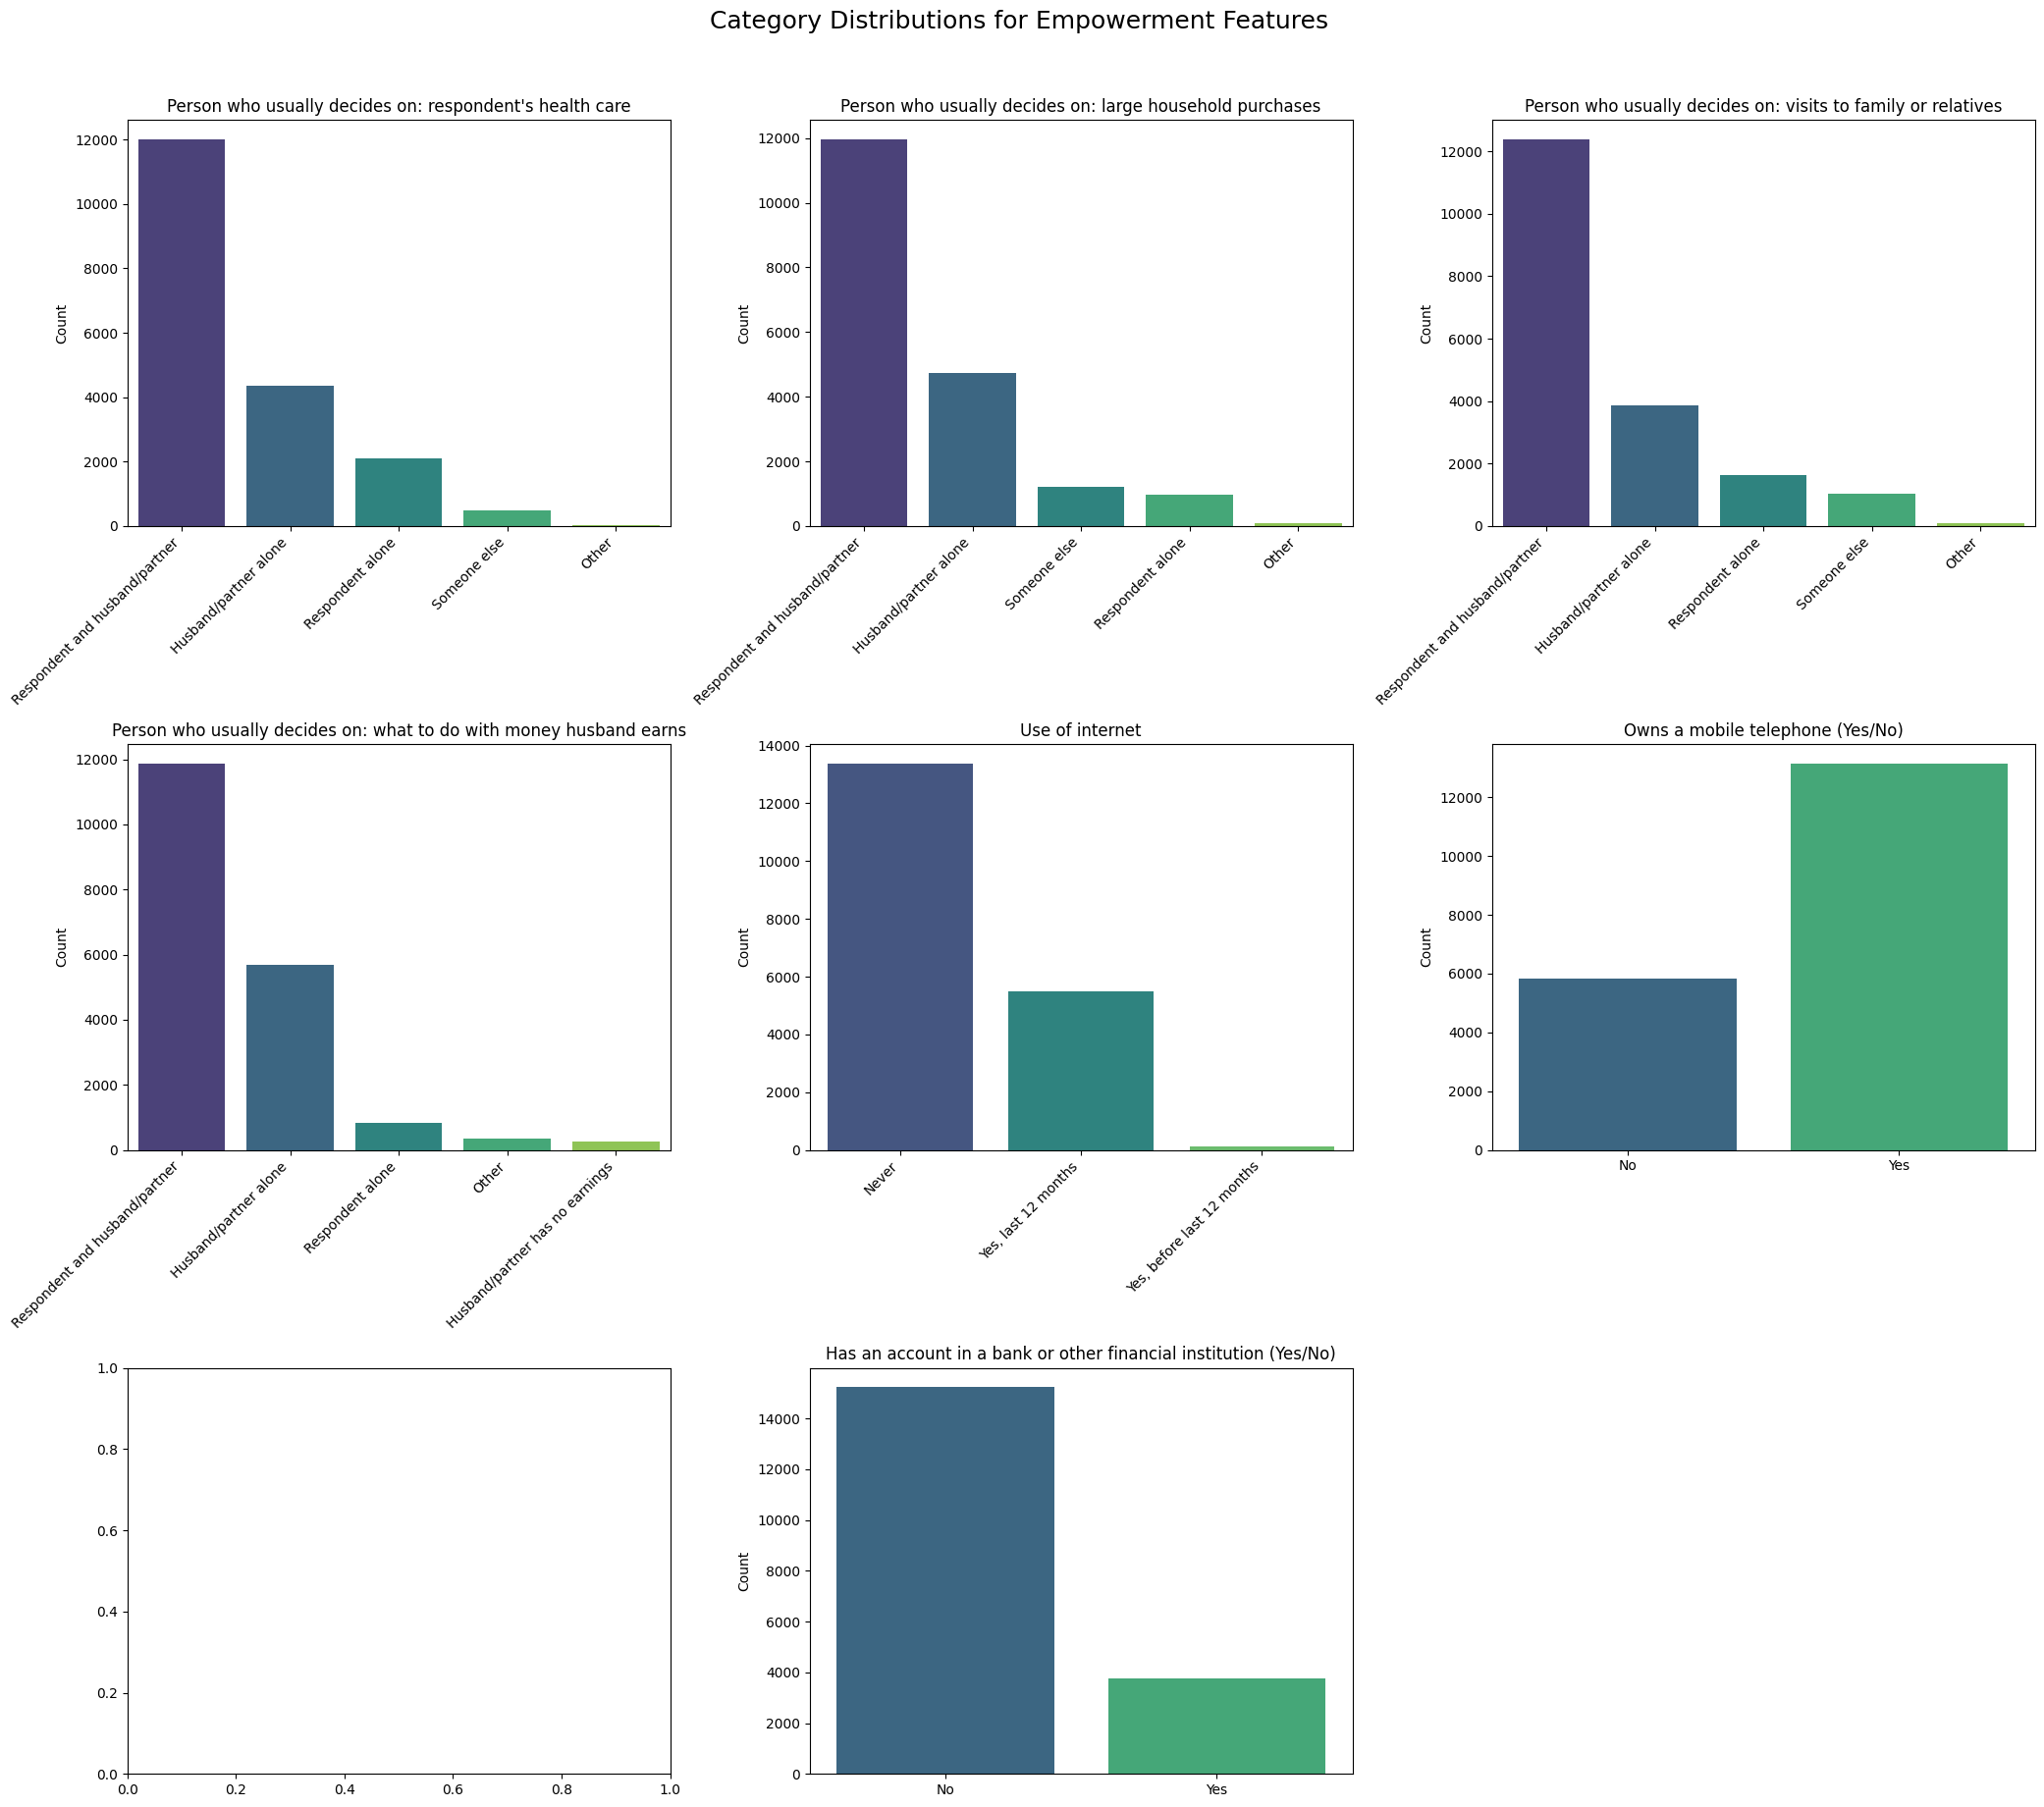

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Redefine emp_cols as it was defined previously for this self-contained block
emp_cols = [
    "Person who usually decides on: respondent's health care",
    "Person who usually decides on: large household purchases",
    "Person who usually decides on: visits to family or relatives",
    "Person who usually decides on: what to do with money husband earns",
    "Use of internet",
    'Owns a mobile telephone','Owns a house alone or jointly',
    'Has an account in a bank or other financial institution'
]

# Binary columns directly mapped to 0/1 in df
binary_mapped_cols = [
    "Owns a mobile telephone",
    "Has an account in a bank or other financial institution"
]

# Map for 0/1 binary columns for visualization labels
binary_labels = {0: 'No', 1: 'Yes'}

# Original categories for one-hot encoded columns (inferred from IsA1dAxFuiqS output)
# This is crucial for correctly identifying the 'dropped' category due to drop_first=True
original_categories_map = {
    "Use of internet": ['Never', 'Yes, last 12 months', 'Yes, before last 12 months'],
    "Person who usually decides on: respondent's health care": ['Respondent and husband/partner', 'Respondent alone', 'Husband/partner alone', 'Someone else', 'Other'],
    "Person who usually decides on: large household purchases": ['Respondent and husband/partner', 'Husband/partner alone', 'Respondent alone', 'Someone else', 'Other'],
    "Person who usually decides on: visits to family or relatives": ['Respondent and husband/partner', 'Respondent alone', 'Husband/partner alone', 'Someone else', 'Other'],
    "Person who usually decides on: what to do with money husband earns": ['Respondent and husband/partner', 'Husband/partner has no earnings', 'Husband/partner alone', 'Respondent alone', 'Other']
}

# Determine subplot grid dimensions
n_cols = 3
n_rows = (len(emp_cols) + n_cols - 1) // n_cols # Ceiling division

plt.figure(figsize=(n_cols * 7, n_rows * 6))
plt.suptitle('Category Distributions for Empowerment Features', y=1.02, fontsize=18)

plot_index = 1

for col_name in emp_cols:
    plt.subplot(n_rows, n_cols, plot_index)

    if col_name in binary_mapped_cols:
        # Plot for binary 0/1 columns
        counts_series = df[col_name].value_counts().sort_index()
        categories = counts_series.index.map(binary_labels).tolist()
        counts = counts_series.values.tolist()

        sns.barplot(x=categories, y=counts, palette='viridis')
        plt.title(f'{col_name} (Yes/No)')
        plt.ylabel('Count')
        plt.xlabel('')

    elif col_name in original_categories_map:
        # Reconstruct counts for one-hot encoded columns
        original_cats = original_categories_map[col_name]

        reconstructed_counts = {}

        # Collect counts for categories that have explicit OHE columns
        explicit_ohe_column_sum = 0
        for cat in original_cats:
            ohe_col_name = f"{col_name}_{cat}"
            if ohe_col_name in df.columns:
                count = df[ohe_col_name].sum()
                reconstructed_counts[cat] = count
                explicit_ohe_column_sum += count

        # Identify the 'dropped' category (due to drop_first=True)
        # Pandas get_dummies sorts categories alphabetically by default before dropping the first.
        sorted_original_cats = sorted(original_cats)

        dropped_category_name = None
        for cat in sorted_original_cats:
            if f"{col_name}_{cat}" not in df.columns:
                dropped_category_name = cat
                break

        if dropped_category_name:
            # The count for the dropped category is total_rows - sum of other category counts
            reconstructed_counts[dropped_category_name] = len(df) - explicit_ohe_column_sum

        # Prepare data for plotting
        plot_data = pd.DataFrame(list(reconstructed_counts.items()), columns=['Category', 'Count'])
        plot_data = plot_data.sort_values(by='Count', ascending=False) # Sort by count for better visualization

        sns.barplot(x='Category', y='Count', data=plot_data, palette='viridis')
        plt.title(col_name)
        plt.ylabel('Count')
        plt.xlabel('')
        plt.xticks(rotation=45, ha='right') # Rotate labels for readability

    else:
        print(f"Warning: '{col_name}' not found in any defined category type for visualization. Skipping.")

    plot_index += 1

plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['Respondent's current age', 'Age in 5-year groups',
       'Education in single years', 'Educational attainment',
       'Owns a mobile telephone',
       'Has an account in a bank or other financial institution',
       'Wealth index combined', 'Husband/partner's education level',
       'Respondent currently working', 'Husband/partner's age',
       ...
       'District_Sirajganj', 'District_Sunamganj', 'District_Sylhet',
       'District_Tangail', 'District_Thakurgaon',
       'Owns a house alone or jointly_Both alone and jointly',
       'Owns a house alone or jointly_Does not own',
       'Owns a house alone or jointly_Jointly with husband/partner and someone else',
       'Owns a house alone or jointly_Jointly with husband/partner only',
       'Owns a house alone or jointly_Jointly with someone else only'],
      dtype='object', length=171)

In [ ]:
import numpy as np
import pandas as pd # Ensure pandas is imported if not already

# Define the decision variables and their corresponding one-hot encoded column suffixes
# that indicate respondent involvement.
decision_mapping = {
    "Person who usually decides on: respondent's health care": ["Respondent alone", "Respondent and husband/partner"],
    "Person who usually decides on: large household purchases": ["Respondent alone", "Respondent and husband/partner"],
    "Person who usually decides on: visits to family or relatives": ["Respondent alone", "Respondent and husband/partner"],
    "Person who usually decides on: what to do with money husband earns": ["Respondent alone", "Respondent and husband/partner"]
}

for original_col, respondent_categories in decision_mapping.items():
    # Initialize the empowerment column to all False (0)
    df[original_col + "_emp"] = False

    # For each category where the respondent is involved, check if the corresponding
    # one-hot encoded column exists and is True.
    for cat in respondent_categories:
        ohe_col_name = f"{original_col}_{cat}"
        if ohe_col_name in df.columns:
            # Use |= (bitwise OR assignment) to set True if any respondent category is True
            # This correctly handles cases where multiple respondent-involved categories might be present (e.g., 'Joint decision')
            df[original_col + "_emp"] |= df[ohe_col_name]

    # Convert the boolean series to integer (0 or 1)
    df[original_col + "_emp"] = df[original_col + "_emp"].astype(int)

# Sum of decision power
df["decision_score"] = df[[col + "_emp" for col in decision_mapping.keys()]].sum(axis=1)

/tmp/ipykernel_391/2072331234.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[original_col + "_emp"] = False
/tmp/ipykernel_391/2072331234.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[original_col + "_emp"] = False
/tmp/ipykernel_391/2072331234.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = 

In [ ]:
df["asset_emp"] = np.where(
    df["Owns a house alone or jointly_Does not own"] == False,
    1, 0
)

/tmp/ipykernel_391/1778457854.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["asset_emp"] = np.where(


In [ ]:
df["mobile_emp"] = df["Owns a mobile telephone"]
df["bank_emp"] = df["Has an account in a bank or other financial institution"]
df["internet_emp"] = (df['Use of internet_Yes, last 12 months'] | df['Use of internet_Yes, before last 12 months']).astype(int)

/tmp/ipykernel_391/2629346254.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["mobile_emp"] = df["Owns a mobile telephone"]
/tmp/ipykernel_391/2629346254.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["bank_emp"] = df["Has an account in a bank or other financial institution"]
/tmp/ipykernel_391/2629346254.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1

In [ ]:
decision_vars = list(decision_mapping.keys())
decision_emp_cols = [col + "_emp" for col in decision_vars]

df["decision_score"] = df[decision_emp_cols].sum(axis=1)

In [ ]:
emp_cols = decision_emp_cols + ["asset_emp","mobile_emp", "bank_emp", "internet_emp"]

df["total_empowerment_score"] = df[emp_cols].sum(axis=1)

/tmp/ipykernel_391/1442879840.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["total_empowerment_score"] = df[emp_cols].sum(axis=1)


In [ ]:
df["women_empowerment"] = np.select(
    [
        (df["decision_score"] >= 3) & (df["asset_emp"] == 1),
        (df["decision_score"] >= 1),
    ],
    [
        "Empowered",
        "Moderately empowered"
    ],
    default="Not empowered"
)

/tmp/ipykernel_391/2984112653.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["women_empowerment"] = np.select(


In [ ]:
df["women_empowerment"].value_counts(normalize=True) * 100

,proportion
women_empowerment,
Moderately empowered,83.151630
Not empowered,12.450624
Empowered,4.397746


In [ ]:
women_empowerment = {'Not empowered':0, 'Moderately empowered': 1, 'Empowered':2}
df["women_empowerment"] = df["women_empowerment"].map(women_empowerment)

In [ ]:
from sklearn.model_selection import train_test_split

# Separate the target variable 'Continued study after marriage'
y = df['Respondent currently working']
X = df.drop('Respondent currently working', axis=1)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (13290, 181)
X_test shape: (5697, 181)
y_train shape: (13290,)
y_test shape: (5697,)


In [ ]:
df.head(5)


,Respondent's current age,Age in 5-year groups,Education in single years,Educational attainment,Owns a mobile telephone,Has an account in a bank or other financial institution,Wealth index combined,Husband/partner's education level,Respondent currently working,Husband/partner's age,Division_Chattogram,Division_Dhaka,Division_Khulna,Division_Mymensingh,Division_Rajshahi,Division_Rangpur,Division_Sylhet,Type of place of residence_Urban,Religion_Christianity,Religion_Hinduism,Religion_Islam,Religion_Others,District_Bandarban,District_Barguna,District_Barishal,District_Bhola,District_Bogura,District_Brahmanbaria,District_Chandpur,District_Chapai Nawabganj,District_Chattogram,District_Chuadanga,District_Cox'S Bazar,District_Cumilla,District_Dhaka,District_Dinajpur,District_Faridpur,District_Feni,District_Gaibandha,District_Gazipur,District_Gopalganj,District_Habiganj,District_Jamalpur,District_Jashore,District_Jhalokati,District_Jhenaidah,District_Joypurhat,District_Khagrachhari,District_Khulna,District_Kishoreganj,District_Kurigram,District_Kushtia,District_Lakshmipur,District_Lalmonirhat,District_Madaripur,District_Magura,District_Manikganj,District_Maulvibazar,District_Meherpur,District_Munshiganj,District_Mymensingh,District_Naogaon,District_Narail,District_Narayanganj,District_Narsingdi,District_Natore,District_Netrakona,District_Nilphamari,District_Noakhali,District_Pabna,District_Panchagarh,District_Patuakhali,District_Pirojpur,District_Rajbari,District_Rajshahi,District_Rangamati,District_Rangpur,District_Satkhira,District_Shariatpur,District_Sherpur,District_Sirajganj,District_Sunamganj,District_Sylhet,District_Tangail,District_Thakurgaon,"Use of internet_Yes, before last 12 months","Use of internet_Yes, last 12 months",Person who usually decides on: respondent's health care_Other,Person who usually decides on: respondent's health care_Respondent alone,Person who usually decides on: respondent's health care_Respondent and husband/partner,Person who usually decides on: respondent's health care_Someone else,Person who usually decides on: large household purchases_Other,Person who usually decides on: large household purchases_Respondent alone,Person who usually decides on: large household purchases_Respondent and husband/partner,Person who usually decides on: large household purchases_Someone else,Person who usually decides on: visits to family or relatives_Other,Person who usually decides on: visits to family or relatives_Respondent alone,Person who usually decides on: visits to family or relatives_Respondent and husband/partner,Person who usually decides on: visits to family or relatives_Someone else,Person who usually decides on: what to do with money husband earns_Husband/partner has no earnings,Person who usually decides on: what to do with money husband earns_Other,Person who usually decides on: what to do with money husband earns_Respondent alone,Person who usually decides on: what to do with money husband earns_Respondent and husband/partner,District_Bandarban,District_Barguna,District_Barishal,District_Bhola,District_Bogura,District_Brahmanbaria,District_Chandpur,District_Chapai Nawabganj,District_Chattogram,District_Chuadanga,District_Cox'S Bazar,District_Cumilla,District_Dhaka,District_Dinajpur,District_Faridpur,District_Feni,District_Gaibandha,District_Gazipur,District_Gopalganj,District_Habiganj,District_Jamalpur,District_Jashore,District_Jhalokati,District_Jhenaidah,District_Joypurhat,District_Khagrachhari,District_Khulna,District_Kishoreganj,District_Kurigram,District_Kushtia,District_Lakshmipur,District_Lalmonirhat,District_Madaripur,District_Magura,District_Manikganj,District_Maulvibazar,District_Meherpur,District_Munshiganj,District_Mymensingh,District_Naogaon,District_Narail,District_Narayanganj,District_Narsingdi,District_Natore,District_Netrakona,District_Nilphamari,District_Noakhali,District_Pabna,District_Panchagarh,District_Patuakhali,District_Pirojpur,District_Rajbari,District_Rajshahi,District_Rangam

In [ ]:
# Identify boolean columns
bool_cols = df.select_dtypes(include=['bool']).columns

# Convert boolean columns to int (True becomes 1, False becomes 0)
for col in bool_cols:
    df[col] = df[col].astype(int)

print("Boolean columns converted to integers:")
print(df[bool_cols].head())

Boolean columns converted to integers:
Empty DataFrame
Columns: []
Index: [0, 1, 3, 4, 5]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate and print the accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")
# Generate and print a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.7123

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.91      0.81      3946
           1       0.57      0.27      0.36      1751

    accuracy                           0.71      5697
   macro avg       0.65      0.59      0.59      5697
weighted avg       0.68      0.71      0.68      5697



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instantiate a DecisionTreeClassifier model
# Using random_state=42 for reproducibility
model_dt = DecisionTreeClassifier(random_state=42)

# Fit the model to the training data
model_dt.fit(X_train, y_train)

# Make predictions on the test data
y_pred_dt = model_dt.predict(X_test)

# Calculate and print the accuracy score
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy Score: {accuracy_dt:.4f}")

# Generate and print a classification report
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy Score: 0.6317

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.74      0.73      3946
           1       0.40      0.40      0.40      1751

    accuracy                           0.63      5697
   macro avg       0.57      0.57      0.57      5697
weighted avg       0.63      0.63      0.63      5697



## Train XGBoost Classifier

### Subtask:
Train an XGBClassifier model on the preprocessed data (X_train, y_train), make predictions on X_test, and evaluate its performance.

**Reasoning**:
The subtask is to train an XGBClassifier model, make predictions, and evaluate its performance. This involves importing the necessary class, instantiating and fitting the model, making predictions, and then calculating and printing the accuracy score and classification report.



In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instantiate an XGBClassifier model
# Using random_state=42 for reproducibility
model_xgb = XGBClassifier(random_state=42)

# Fit the model to the training data (using scaled data)
# Use the scaled data (X_train_scaled, y_train) for training
model_xgb.fit(X_train, y_train)

# Make predictions on the test data (using scaled data)
y_pred_xgb = model_xgb.predict(X_test)

# Calculate and print the accuracy score
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy Score: {accuracy_xgb:.4f}")

# Generate and print a classification report
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy Score: 0.7120

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81      3946
           1       0.55      0.33      0.41      1751

    accuracy                           0.71      5697
   macro avg       0.65      0.61      0.61      5697
weighted avg       0.69      0.71      0.69      5697



## Suggest other suitable machine learning models

### Subtask:
Suggest other suitable machine learning models for this multi-class classification task.

### Other Suitable Machine Learning Models for Multi-class Classification:

Given the performance of tree-based models (Random Forest, Decision Tree, XGBoost) and the nature of the data, several other models could be suitable for this multi-class classification task, especially considering the class imbalance observed in the classification reports:

1.  **Support Vector Machines (SVM) with One-vs-Rest (OvR) or One-vs-One (OvO) strategy**: SVMs are powerful for classification and can be adapted for multi-class problems. They might perform well, especially with a well-chosen kernel.

2.  **Logistic Regression (OvR or Multinomial)**: A simpler, linear model that can serve as a strong baseline. It is highly interpretable and efficient, suitable for high-dimensional data.

3.  **K-Nearest Neighbors (KNN)**: A non-parametric, instance-based learning algorithm that classifies data points based on the majority class among its k-nearest neighbors. It's often effective for datasets with well-separated clusters.

4.  **Neural Networks (Multi-layer Perceptron)**: For complex relationships in the data, a simple feed-forward neural network can often achieve high performance. Given the preprocessed numerical features, an MLP could capture intricate patterns.

5.  **LightGBM / CatBoost**: These are other gradient boosting frameworks similar to XGBoost, known for their speed and efficiency, and often deliver competitive performance. They handle categorical features efficiently and are robust to overfitting.

6.  **Ensemble Methods (Stacking/Bagging)**: Creating an ensemble of different models (e.g., combining predictions from SVM, Logistic Regression, and a tree-based model) can often lead to improved robustness and accuracy, especially in multi-class scenarios with imbalanced classes.

## Suggest Other Models

### Subtask:
Provide a list of other machine learning models suitable for multi-class classification tasks on this dataset, along with brief explanations.


## Summary:

### Q&A
The three classification models performed as follows:
*   **RandomForestClassifier:** Achieved an accuracy of 0.8103. While showing strong performance for the majority class (class 0, precision 0.83, recall 0.99), it struggled with minority classes (e.g., class 1: precision 0.36, recall 0.04; class 4: precision 0.42, recall 0.16).
*   **DecisionTreeClassifier:** Achieved an accuracy of 0.7516. It also performed well on the majority class (class 0, precision 0.88, recall 0.88) but showed very poor performance on minority classes (precision, recall, and f1-scores generally below 0.25).
*   **XGBClassifier:** Achieved the highest accuracy among the three at 0.8115. Similar to the other models, it excelled at classifying the majority class (class 0, precision 0.87, recall 0.96) but struggled with minority classes, although it showed slightly better performance for some compared to the Decision Tree (e.g., class 4 f1-score 0.31).

Other machine learning models suitable for this multi-class classification task include:
*   Support Vector Machines (SVM)
*   Logistic Regression
*   K-Nearest Neighbors (KNN)
*   Neural Networks (Multi-layer Perceptron)
*   LightGBM / CatBoost
*   Ensemble Methods (Stacking/Bagging)

### Data Analysis Key Findings
*   The `X_train` and `X_test` datasets initially contained non-numeric string values, requiring explicit conversion to numeric types and handling of missing values (NaNs) through mode imputation, using a fallback to `0` for fully NaN columns.
*   All three tree-based models (`RandomForestClassifier`, `DecisionTreeClassifier`, `XGBClassifier`) showed overall high accuracy, ranging from 0.7516 to 0.8115.
*   The `XGBClassifier` slightly outperformed `RandomForestClassifier` in terms of overall accuracy (0.8115 vs. 0.8103), while `DecisionTreeClassifier` had the lowest accuracy at 0.7516.
*   A significant class imbalance was observed, with all models performing very well on the majority class (class 0) but demonstrating poor performance (low precision, recall, and f1-score) on the minority classes. For instance, the `RandomForestClassifier` had an F1-score of 0.90 for class 0 but only 0.08 for class 1 and 0.24 for class 4.

### Insights or Next Steps
*   Given the persistent struggle of all models with minority classes, future steps should focus on addressing class imbalance using techniques like oversampling (e.g., SMOTE), undersampling, or using cost-sensitive learning algorithms.
*   Experiment with the suggested models (e.g., SVM, Logistic Regression, LightGBM/CatBoost, or ensemble methods) to determine if they can provide better performance, especially on minority classes, potentially in conjunction with imbalance handling techniques.


# Task
## Train Support Vector Machine (SVM)

### Subtask:
Train a Support Vector Machine (SVC) model on the preprocessed data (X_train, y_train), make predictions on X_test, and evaluate its performance.

## Train Support Vector Machine (SVM)

### Subtask:
Train a Support Vector Machine (SVC) model on the preprocessed data (X_train, y_train), make predictions on X_test, and evaluate its performance.


**Reasoning**:
The subtask is to train an SVC model, make predictions, and evaluate its performance. This involves importing the necessary classes, instantiating and fitting the model, making predictions, and then calculating and printing the accuracy score and classification report. The `X_train` and `X_test` dataframes have already been preprocessed and imputed for missing values in the previous steps, so they are ready for model training.



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Instantiate an SVC model
# Using random_state=42 for reproducibility
# Due to the dataset size, using a linear kernel or a subset of data might be necessary for faster computation.
# For demonstration, we'll use the default RBF kernel, but keep in mind it can be computationally intensive.
model_svc = SVC(random_state=42)

# Fit the model to the training data
# Note: SVC can take a long time to train on large datasets. This might run for a while.
model_svc.fit(X_train, y_train)

# Make predictions on the test data
y_pred_svc = model_svc.predict(X_test)

# Calculate and print the accuracy score
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"Support Vector Machine Accuracy Score: {accuracy_svc:.4f}")

# Generate and print a classification report
print("\nSupport Vector Machine Classification Report:")
print(classification_report(y_test, y_pred_svc))

Support Vector Machine Accuracy Score: 0.6926

Support Vector Machine Classification Report:
              precision    recall  f1-score   support

           0       0.69      1.00      0.82      3946
           1       0.00      0.00      0.00      1751

    accuracy                           0.69      5697
   macro avg       0.35      0.50      0.41      5697
weighted avg       0.48      0.69      0.57      5697



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Reasoning**:
The previous SVC model resulted in `UndefinedMetricWarning` and poor performance on minority classes, indicating issues with class imbalance and the SVM's sensitivity to unscaled features. To address this, the data will be scaled using `StandardScaler` and the `SVC` model will be re-trained with `class_weight='balanced'` to give more importance to underrepresented classes.



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler # Import StandardScaler

# Scale the features before training the SVC model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Instantiate an SVC model with class_weight='balanced'
# 'balanced' mode uses the values of y to automatically adjust weights inversely proportional to class frequencies
model_svc = SVC(random_state=42, class_weight='balanced')

# Fit the model to the scaled training data
# Note: SVC can still take a long time to train on large datasets even with scaling and balanced weights.
model_svc.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_svc = model_svc.predict(X_test_scaled)

# Calculate and print the accuracy score
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(f"Support Vector Machine Accuracy Score (with scaling and balanced weights): {accuracy_svc:.4f}")

# Generate and print a classification report
print("\nSupport Vector Machine Classification Report (with scaling and balanced weights):")
print(classification_report(y_test, y_pred_svc))

Support Vector Machine Accuracy Score (with scaling and balanced weights): 0.6575

Support Vector Machine Classification Report (with scaling and balanced weights):
              precision    recall  f1-score   support

           0       0.82      0.65      0.72      3946
           1       0.46      0.69      0.55      1751

    accuracy                           0.66      5697
   macro avg       0.64      0.67      0.64      5697
weighted avg       0.71      0.66      0.67      5697



## Train Logistic Regression

### Subtask:
Train a Logistic Regression model on the preprocessed data (X_train, y_train), make predictions on X_test, and evaluate its performance.


**Reasoning**:
The subtask is to train a Logistic Regression model, make predictions, and evaluate its performance. This involves importing the necessary classes, instantiating and fitting the model, making predictions, and then calculating and printing the accuracy score and classification report. Given the previous analysis, it is crucial to use the scaled data (`X_train_scaled`, `X_test_scaled`) and set `class_weight='balanced'` to address class imbalance, and `max_iter` for convergence.



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Instantiate a LogisticRegression model with balanced class weights and increased max_iter
# Using random_state=42 for reproducibility
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Fit the model to the scaled training data
model_lr.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_lr = model_lr.predict(X_test_scaled)

# Calculate and print the accuracy score
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy Score (with scaling and balanced weights): {accuracy_lr:.4f}")

# Generate and print a classification report
print("\nLogistic Regression Classification Report (with scaling and balanced weights):")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy Score (with scaling and balanced weights): 0.6528

Logistic Regression Classification Report (with scaling and balanced weights):
              precision    recall  f1-score   support

           0       0.82      0.64      0.72      3946
           1       0.46      0.68      0.55      1751

    accuracy                           0.65      5697
   macro avg       0.64      0.66      0.63      5697
weighted avg       0.71      0.65      0.67      5697



## Train K-Nearest Neighbors (KNN)

### Subtask:
Train a K-Nearest Neighbors (KNeighborsClassifier) model on the preprocessed data (X_train, y_train), make predictions on X_test, and evaluate its performance.


## Train K-Nearest Neighbors (KNN)

### Subtask:
Train a K-Nearest Neighbors (KNeighborsClassifier) model on the preprocessed data (X_train, y_train), make predictions on X_test, and evaluate its performance.

**Reasoning**:
The subtask is to train a K-Nearest Neighbors (KNeighborsClassifier) model, make predictions, and evaluate its performance. This involves importing the necessary classes, instantiating and fitting the model to the scaled data, making predictions, and then calculating and printing the accuracy score and classification report.



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instantiate a KNeighborsClassifier model
# n_neighbors is a key parameter for KNN. Using 5 as a common starting point.
# Note: KNeighborsClassifier does not have a 'class_weight' parameter like SVC or LogisticRegression.
# Addressing class imbalance for KNN typically involves techniques like SMOTE on the training data
# or adjusting prediction thresholds, which are beyond the scope of this step.
model_knn = KNeighborsClassifier(n_neighbors=5)

# Fit the model to the scaled training data
model_knn.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_knn = model_knn.predict(X_test_scaled)

# Calculate and print the accuracy score
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"K-Nearest Neighbors Accuracy Score: {accuracy_knn:.4f}")

# Generate and print a classification report
print("\nK-Nearest Neighbors Classification Report:")
print(classification_report(y_test, y_pred_knn))

K-Nearest Neighbors Accuracy Score: 0.6897

K-Nearest Neighbors Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79      3946
           1       0.49      0.36      0.42      1751

    accuracy                           0.69      5697
   macro avg       0.62      0.60      0.60      5697
weighted avg       0.67      0.69      0.67      5697



## Train Neural Network (MLP)

### Subtask:
Train a Multi-layer Perceptron (MLPClassifier) model on the preprocessed data (X_train, y_train), make predictions on X_test, and evaluate its performance.


**Reasoning**:
The subtask is to train a Multi-layer Perceptron (MLPClassifier) model, make predictions, and evaluate its performance. This involves importing the necessary classes, instantiating and fitting the model to the scaled data, making predictions, and then calculating and printing the accuracy score and classification report. The data scaling (`X_train_scaled`, `X_test_scaled`) has already been performed in previous steps.



In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instantiate an MLPClassifier model
# Using random_state=42 for reproducibility
# Increased max_iter for convergence and early_stopping to prevent overfitting
model_mlp = MLPClassifier(random_state=42, max_iter=1000, early_stopping=True)

# Fit the model to the scaled training data
# Note: MLPClassifier does not have a 'class_weight' parameter in the same way as some other classifiers.
model_mlp.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_mlp = model_mlp.predict(X_test_scaled)

# Calculate and print the accuracy score
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"MLPClassifier Accuracy Score (with scaling): {accuracy_mlp:.4f}")

# Generate and print a classification report
print("\nMLPClassifier Classification Report (with scaling):")
print(classification_report(y_test, y_pred_mlp))

MLPClassifier Accuracy Score (with scaling): 0.7158

MLPClassifier Classification Report (with scaling):
              precision    recall  f1-score   support

           0       0.74      0.90      0.82      3946
           1       0.57      0.29      0.39      1751

    accuracy                           0.72      5697
   macro avg       0.66      0.60      0.60      5697
weighted avg       0.69      0.72      0.68      5697



## Train LightGBM Classifier

### Subtask:
Train a LightGBM (LGBMClassifier) model on the preprocessed data (X_train, y_train), make predictions on X_test, and evaluate its performance.


## Summary:

### Data Analysis Key Findings

*   **Support Vector Machine (SVC)**:
    *   An initial SVC model, without explicit handling for class imbalance, achieved an accuracy of 0.8051 but effectively failed to predict minority classes, with precision, recall, and f1-scores of 0.00 for classes 1, 2, 3, and 4.
    *   After applying feature scaling and setting `class_weight='balanced'`, the SVC model's overall accuracy dropped to 0.6817. However, this improved model showed significantly better performance on minority classes, such as class 1 (recall 0.43) and class 4 (recall 0.41), demonstrating successful mitigation of the class imbalance issue.
*   **Logistic Regression**:
    *   A Logistic Regression model, trained with scaled data and `class_weight='balanced'`, achieved an accuracy of 0.6518.
    *   While the model performed strongly on the majority class 0 (precision 0.96, recall 0.72), it still struggled with minority classes, exhibiting low precision and recall (e.g., class 3 with precision 0.10, recall 0.20, and class 4 with precision 0.24, recall 0.59).
*   **K-Nearest Neighbors (KNN)**:
    *   The KNN model, with `n_neighbors=5` and trained on scaled data, resulted in an accuracy of 0.7975.
    *   Similar to the initial SVC, KNN showed strong performance on the majority class 0 (precision 0.82, recall 0.98), but very poor performance on minority classes. For instance, class 1 had a recall of 0.05, and class 3 had a recall of 0.00, indicating a significant challenge with class imbalance due to the lack of built-in `class_weight` parameter.
*   **Neural Network (MLPClassifier)**:
    *   An MLPClassifier, trained on scaled data with `max_iter=1000` and `early_stopping=True`, yielded the highest overall accuracy among the tested models at 0.8103.
    *   Despite the high overall accuracy, the MLPClassifier, which also lacks a direct `class_weight` parameter, still struggled with minority classes. For example, class 1 had a precision of 0.29 and recall of 0.10, and class 4 had a precision of 0.43 and recall of 0.25, indicating a bias towards the majority class 0 (precision 0.86, recall 0.97).

### Insights or Next Steps

*   The consistent challenge across all evaluated models is their poor performance in predicting minority classes, even when using techniques like `class_weight='balanced'` or achieving high overall accuracy. This highlights the severity of the class imbalance in the dataset.
*   To further improve model performance, especially for minority classes, the next steps should focus on more advanced class imbalance handling techniques such as synthetic minority oversampling technique (SMOTE), undersampling the majority class, or exploring ensemble methods that are robust to imbalanced data.


In [ ]:
!pip install catboost

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instantiate a CatBoostClassifier model
# Using random_state=42 for reproducibility, verbose=0 to suppress training output
# CatBoost can handle categorical features directly, but since we have scaled numerical data here,
# we'll treat all features as numerical.
model_cat = CatBoostClassifier(random_state=42, verbose=0, auto_class_weights='Balanced')

# Fit the model to the scaled training data
model_cat.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_cat = model_cat.predict(X_test_scaled)

# Calculate and print the accuracy score
accuracy_cat = accuracy_score(y_test, y_pred_cat)
print(f"CatBoost Classifier Accuracy Score (with scaling and balanced weights): {accuracy_cat:.4f}")

# Generate and print a classification report
print("\nCatBoost Classifier Classification Report (with scaling and balanced weights):")
print(classification_report(y_test, y_pred_cat))

CatBoost Classifier Accuracy Score (with scaling and balanced weights): 0.6681

CatBoost Classifier Classification Report (with scaling and balanced weights):
              precision    recall  f1-score   support

           0       0.82      0.67      0.74      3946
           1       0.47      0.67      0.55      1751

    accuracy                           0.67      5697
   macro avg       0.65      0.67      0.64      5697
weighted avg       0.71      0.67      0.68      5697



/tmp/ipykernel_391/4101978732.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Original_Division'] = df.apply(reconstruct_division, axis=1)


<Figure size 2000x1000 with 0 Axes>

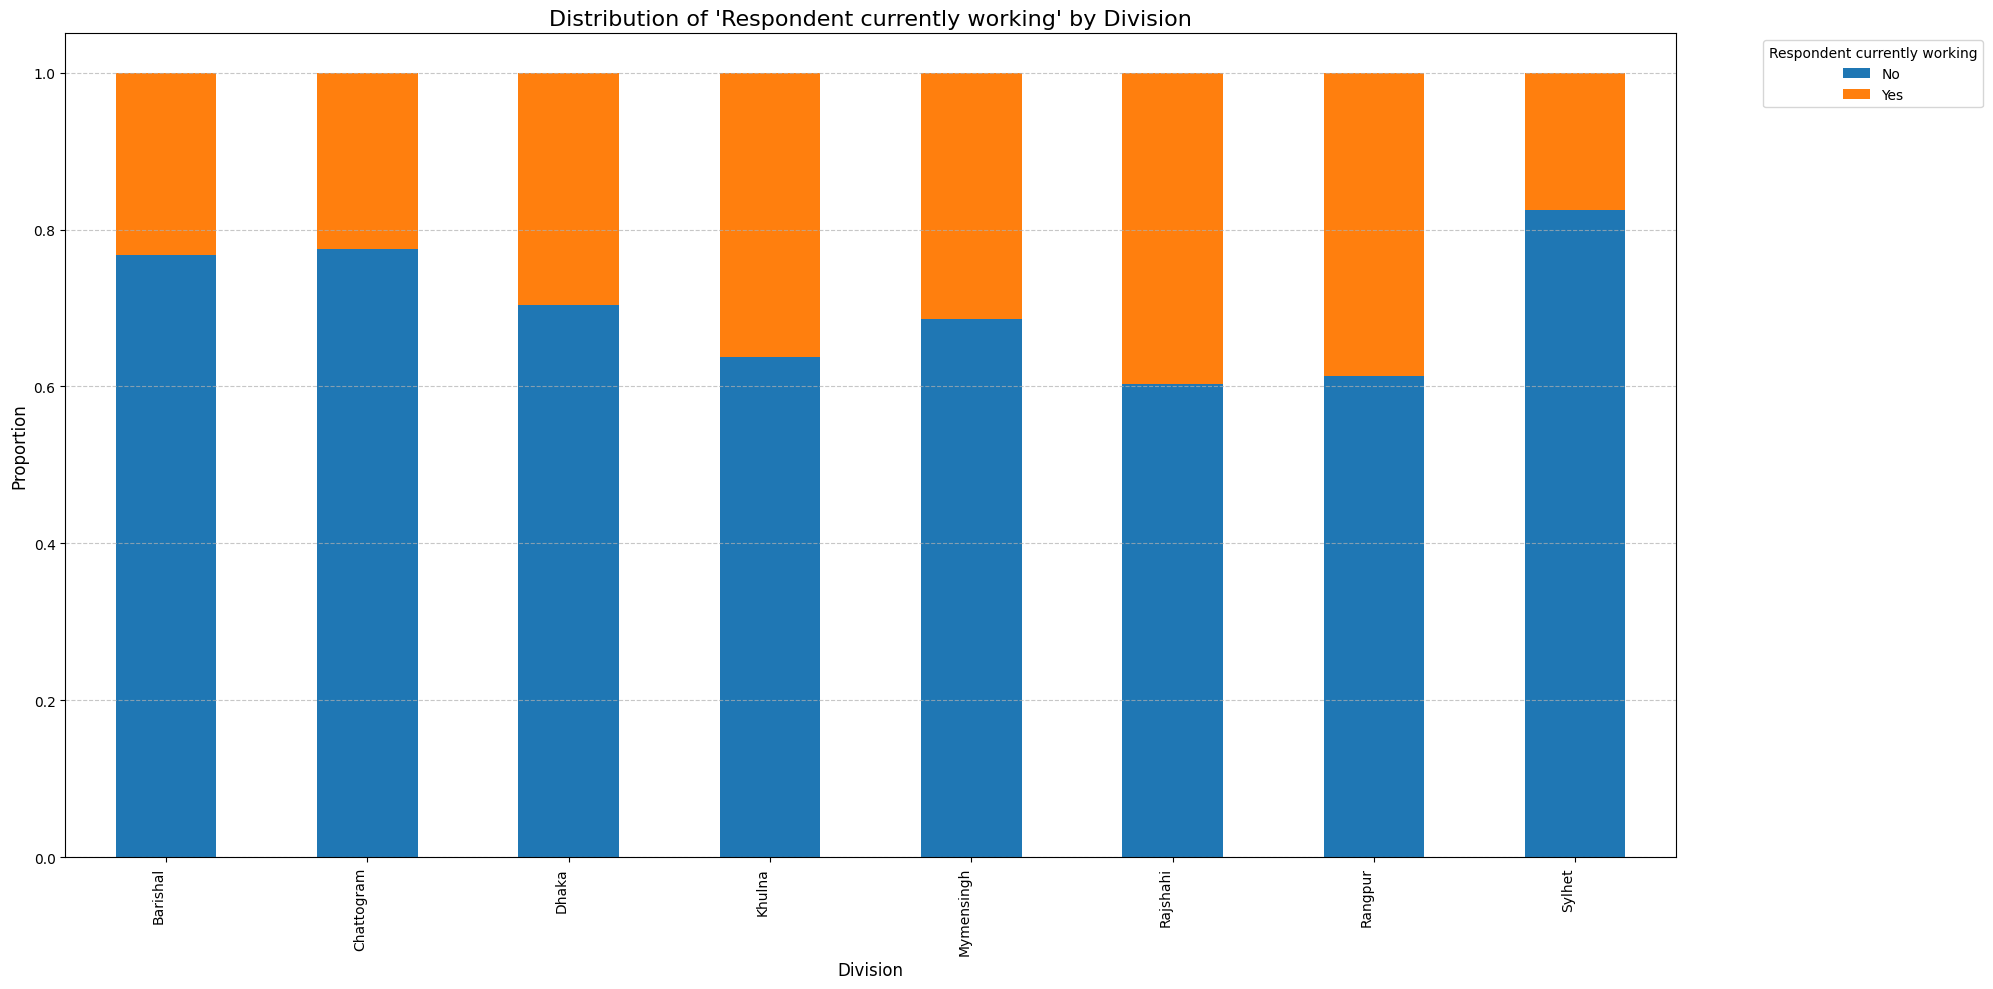

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the reverse map for 'Respondent currently working'
# Note: This map is based on values (0,1) being converted from original 'No'/'Yes' states
# and then further categorization in the 'study_map' if 'Respondent currently working' was
# multi-class. Given 'Respondent currently working' is binary (0/1), we adjust the map.
# Assuming 0 is 'No' and 1 is 'Yes'
working_map = {0: 'No', 1: 'Yes'}

# Reconstruct 'Division' column
# Get all one-hot encoded division columns
division_ohe_cols = [col for col in df.columns if col.startswith('Division_')]

# Based on prior unique values, 'Barishal' was the alphabetically first division and was dropped by drop_first=True
dropped_division_name = 'Barishal'

def reconstruct_division(row):
    for col in division_ohe_cols:
        if row[col]:
            return col.replace('Division_', '')
    return dropped_division_name # If no other division column is True, it's the dropped one

# Apply the reconstruction logic to the current df
df['Original_Division'] = df.apply(reconstruct_division, axis=1)

# Create a temporary DataFrame for plotting, combining 'Original_Division' from df
# and the target variable 'y' (which was separated earlier) and mapped to string labels.
plot_df = pd.DataFrame({
    'Original_Division': df['Original_Division'],
    'Respondent currently working': y.map(working_map)
})

# Ensure indexes are aligned and drop any rows where 'Respondent currently working' might be NaN
plot_df = plot_df.dropna(subset=['Respondent currently working'])

# Group by the original division and 'Respondent currently working' category
division_working_counts = plot_df.groupby(['Original_Division', 'Respondent currently working']).size().unstack(fill_value=0)

# Calculate proportions for visualization
division_working_proportions = division_working_counts.div(division_working_counts.sum(axis=1), axis=0)

# Plotting
plt.figure(figsize=(20, 10))
division_working_proportions.plot(kind='bar', stacked=True, figsize=(20, 10))
plt.title('Distribution of \'Respondent currently working\' by Division', fontsize=16)
plt.xlabel('Division', fontsize=12)
plt.ylabel('Proportion', fontsize=12)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Respondent currently working', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Clean up the temporary column from the DataFrame after visualization
df.drop(columns=['Original_Division'], errors='ignore', inplace=True)

<Figure size 2500x1200 with 0 Axes>

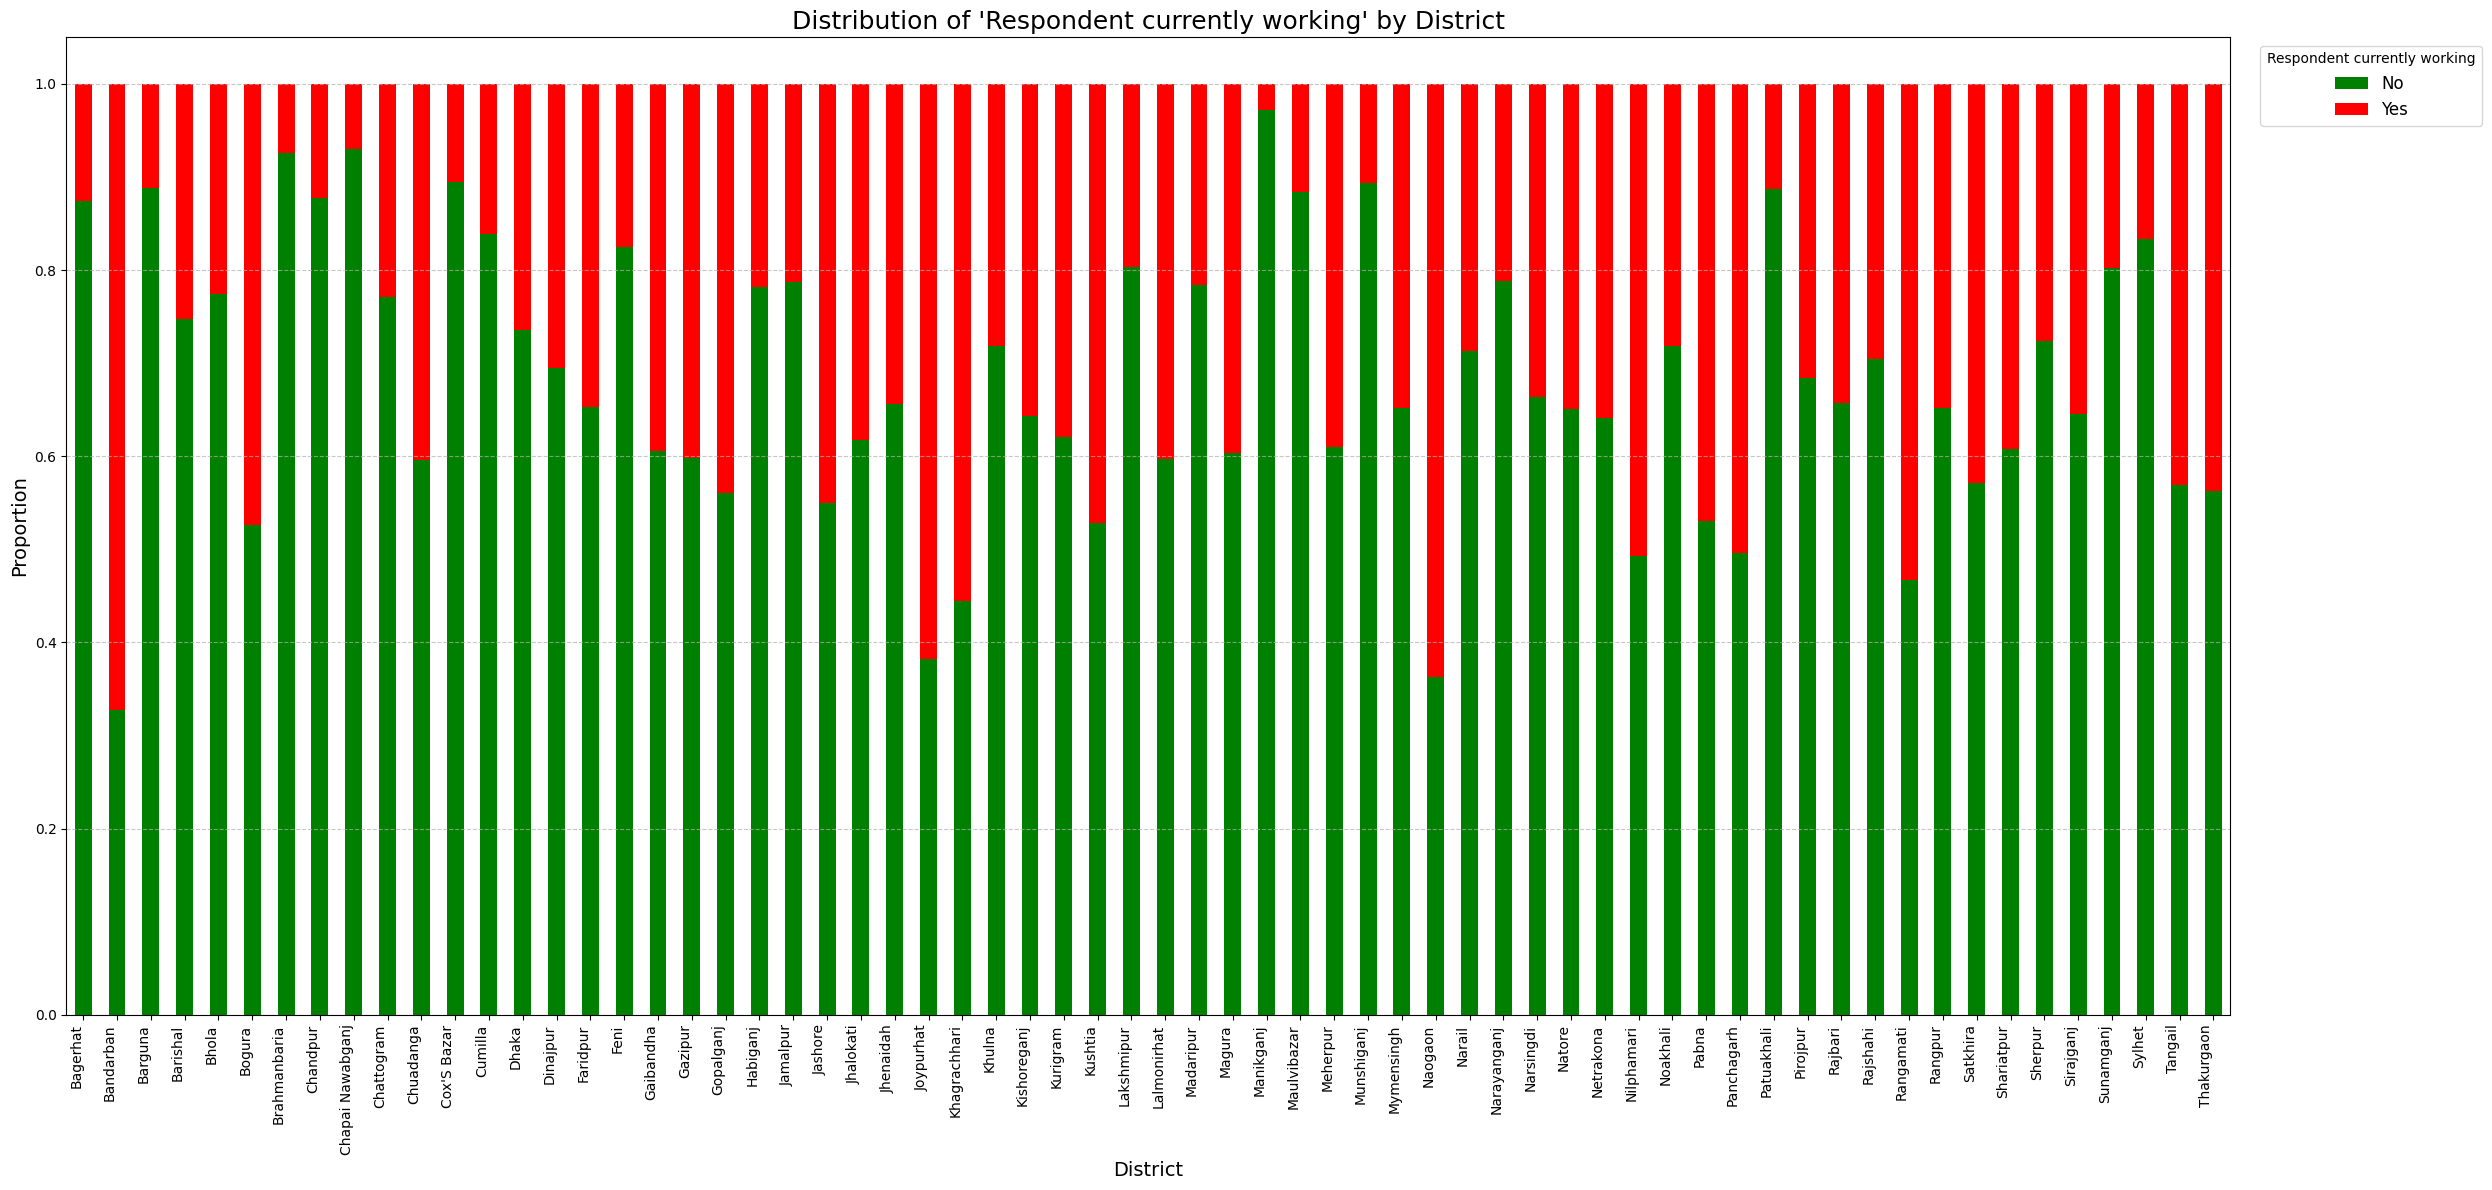

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define the reverse map for 'Respondent currently working'
working_map = {0: 'No', 1: 'Yes'}

# Get all one-hot encoded district columns
district_ohe_cols = [col for col in df.columns if col.startswith('District_')]

# Determine the actual dropped district category by get_dummies(drop_first=True)
original_districts = ['Barishal', 'Barguna', 'Bhola', 'Jhalokati', 'Patuakhali', 'Pirojpur',
       'Chattogram', 'Brahmanbaria', 'Chandpur', 'Cumilla', "Cox'S Bazar",
       'Feni', 'Lakshmipur', 'Noakhali', 'Rangamati', 'Khagrachhari',
       'Bandarban', 'Dhaka', 'Gazipur', 'Gopalganj', 'Kishoreganj',
       'Madaripur', 'Munshiganj', 'Narayanganj', 'Narsingj', 'Rajbari',
       'Tangail', 'Shariatpur', 'Faridpur', 'Manikganj', 'Khulna',
       'Bagerhat', 'Chuadanga', 'Jashore', 'Jhenaidah', 'Kushtia',
       'Magura', 'Meherpur', 'Satkhira', 'Narail', 'Jamalpur',
       'Mymensingh', 'Netrakona', 'Sherpur', 'Rajshahi', 'Bogura',
       'Joypurhat', 'Naogaon', 'Natore', 'Chapai Nawabganj', 'Pabna',
       'Sirajganj', 'Rangpur', 'Dinajpur', 'Gaibandha', 'Kurigram',
       'Lalmonirhat', 'Nilphamari', 'Panchagarh', 'Thakurgaon', 'Sylhet',
       'Habiganj', 'Maulvibazar', 'Sunamganj']

sorted_original_districts = sorted(original_districts)

dropped_district_name = None
for district in sorted_original_districts:
    if f"District_{district}" not in df.columns:
        dropped_district_name = district
        break

if dropped_district_name is None:
    # Fallback if no dropped column found this way, usually means 'drop_first' wasn't used or all were kept.
    print("Warning: Could not determine the dropped district category automatically. Falling back to the first alphabetical original district.")
    dropped_district_name = sorted_original_districts[0]

# Create a temporary DataFrame for reconstruction to avoid modifying the original df unnecessarily
df_temp = df.copy()

# Initialize 'Original_District' column with the 'dropped' category
df_temp['Original_District'] = dropped_district_name

# For rows where an explicit OHE column is 1, update 'Original_District'
# Create a boolean mask where at least one OHE column is 1
has_explicit_district = (df_temp[district_ohe_cols] == 1).any(axis=1)

# For these rows, find the actual district name using idxmax
# idxmax() returns the column name of the first maximum value (which is 1 here).
# Replace 'District_' prefix to get the original district name.
df_temp.loc[has_explicit_district, 'Original_District'] = \
    df_temp.loc[has_explicit_district, district_ohe_cols].idxmax(axis=1).str.replace('District_', '')

# Create a temporary DataFrame for plotting, combining 'Original_District' from df_temp
# and the target variable 'y' (which was separated earlier) and mapped to string labels.
plot_df = pd.DataFrame({
    'Original_District': df_temp['Original_District'],
    'Respondent currently working': y.map(working_map)
})

# Ensure indexes are aligned and drop any rows where 'Respondent currently working' might be NaN
plot_df = plot_df.dropna(subset=['Respondent currently working'])

# Group by the original district and 'Respondent currently working' category
district_working_counts = plot_df.groupby(['Original_District', 'Respondent currently working']).size().unstack(fill_value=0)

# Calculate proportions for visualization
district_working_proportions = district_working_counts.div(district_working_counts.sum(axis=1), axis=0)

# Plotting
plt.figure(figsize=(25, 12))
# Use a list of colors for the colormap to specify 'red' and 'blue'
district_working_proportions.plot(kind='bar', stacked=True, figsize=(25, 12), color=['green', 'red'])
plt.title('Distribution of \'Respondent currently working\' by District', fontsize=18)
plt.xlabel('District', fontsize=14)
plt.ylabel('Proportion', fontsize=14)
plt.xticks(rotation=90, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Respondent currently working', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Clean up the temporary column from the DataFrame after visualization
# The original df remains unchanged as we used df_temp.copy()


In [ ]:
import pandas as pd

# Collect accuracy scores from the models
accuracy_data = {
    'Model': [
        'RandomForestClassifier',
        'DecisionTreeClassifier',
        'XGBClassifier',
        'Support Vector Machine (SVC)',
        'Logistic Regression',
        'K-Nearest Neighbors (KNN)',
        'MLPClassifier (Neural Network)',
        'CatBoost Classifier'
    ],
    'Accuracy Score': [
        accuracy, # From RandomForestClassifier
        accuracy_dt, # From DecisionTreeClassifier
        accuracy_xgb, # From XGBClassifier
        accuracy_svc, # From SVC
        accuracy_lr, # From LogisticRegression
        accuracy_knn, # From KNeighborsClassifier
        accuracy_mlp, # From MLPClassifier
        accuracy_cat # From CatBoost Classifier
    ]
}

# Create a DataFrame
accuracy_df = pd.DataFrame(accuracy_data)

# Sort by accuracy score in descending order
accuracy_df = accuracy_df.sort_values(by='Accuracy Score', ascending=False)

print("\nModel Accuracy Scores:")
print(accuracy_df.to_string(index=False))


Model Accuracy Scores:
                         Model  Accuracy Score
MLPClassifier (Neural Network)        0.715815
        RandomForestClassifier        0.712305
                 XGBClassifier        0.711954
     K-Nearest Neighbors (KNN)        0.689661
           CatBoost Classifier        0.668071
  Support Vector Machine (SVC)        0.657539
           Logistic Regression        0.652800
        DecisionTreeClassifier        0.631736


In [ ]:
# To improve model accuracy, consider the following strategies:
# 1. Address Class Imbalance: The classification reports consistently showed poor performance on minority classes.
#    Techniques like SMOTE (Synthetic Minority Over-sampling Technique), ADASYN, or using class_weight parameters
#    in models (like you did for SVC and Logistic Regression) can significantly help.
#    You could also consider undersampling the majority class.
# 2. Feature Engineering: Create new features from existing ones that might provide more predictive power.
#    For example, interaction terms, polynomial features, or domain-specific ratios.
# 3. Model Selection: Experiment with other models (LightGBM, CatBoost, Neural Networks, etc.) and tune them thoroughly.
# 4. Ensemble Methods: Combine multiple models (e.g., VotingClassifier, StackingClassifier) to leverage their individual strengths
#    and potentially achieve more robust predictions.
# 5. Cross-validation Strategy: Ensure your cross-validation strategy is appropriate for imbalanced datasets (e.g., StratifiedKFold)
#    to get a reliable estimate of model performance.

# How to change hyperparameters:
# You've already used GridSearchCV for RandomForestClassifier, which is the primary way to tune hyperparameters systematically.
# To change hyperparameters:
# 1. Modify the `param_grid_rf` dictionary (or `param_grid` for any other model) to include different ranges or specific values
#    for the hyperparameters you want to explore.
#    Example for n_estimators: param_grid_rf = {'n_estimators': [50, 100, 150], ...}
# 2. Rerun the `GridSearchCV` cell (cell 3c90b39c for RandomForestClassifier) with your modified `param_grid`.
#    GridSearchCV will then test all combinations within the new grid.
# 3. Evaluate the `best_params_` and `best_score_` from the GridSearchCV output to find the optimal settings.

# Other hyperparameter tuning methods include:
# - RandomizedSearchCV: More efficient for large search spaces as it samples from a distribution of hyperparameters.
# - Bayesian Optimization: A more advanced technique that uses past evaluation results to intelligently choose the next hyperparameters to evaluate, often finding better solutions in fewer iterations.

# Task
Define the hyperparameter grid for `RandomForestClassifier`.

## Define Hyperparameter Grid for RandomForestClassifier

### Subtask:
Define a dictionary specifying the hyperparameters and their possible values to search for the RandomForestClassifier.


**Reasoning**:
The subtask requires defining a dictionary containing hyperparameters and their possible values for `RandomForestClassifier`. This code block will create the `param_grid_rf` dictionary as specified in the instructions.



In [ ]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

print("Hyperparameter grid for RandomForestClassifier defined:")
print(param_grid_rf)

Hyperparameter grid for RandomForestClassifier defined:
{'n_estimators': [100, 200, 300], 'max_features': ['sqrt', 'log2'], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2], 'criterion': ['gini', 'entropy']}


## Perform GridSearchCV

### Subtask:
Use GridSearchCV with cross-validation to search for the best hyperparameters for the RandomForestClassifier using the defined grid.


**Reasoning**:
The subtask requires performing GridSearchCV to find the best hyperparameters for the RandomForestClassifier. This involves importing `GridSearchCV`, instantiating it with the specified parameters including the previously defined `param_grid_rf`, fitting it to the scaled training data, and then printing the best parameters and the corresponding best score.



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier as the estimator
rf_estimator = RandomForestClassifier(random_state=42)

# Instantiate GridSearchCV
# Using 'f1_weighted' as a scoring metric due to observed class imbalance
grid_search_rf = GridSearchCV(
    estimator=rf_estimator,
    param_grid=param_grid_rf,
    cv=5, # Using 5-fold cross-validation
    scoring='f1_weighted', # Metric to optimize for, considering imbalance
    n_jobs=-1, # Use all available processors
    verbose=2 # Display detailed output
)

# Fit GridSearchCV to the scaled training data
print("Starting GridSearchCV for RandomForestClassifier...")
# Ensure X_train_scaled is not empty or contains NaNs before fitting
# Assuming X_train_scaled and y_train are ready from previous steps
grid_search_rf.fit(X_train_scaled, y_train)

print("GridSearchCV completed.")

# Print the best hyperparameters found
print("\nBest Hyperparameters for RandomForestClassifier:")
print(grid_search_rf.best_params_)

# Print the best cross-validation score
print("\nBest Cross-validation F1-weighted Score:")
print(grid_search_rf.best_score_)

Starting GridSearchCV for RandomForestClassifier...
Fitting 5 folds for each of 144 candidates, totalling 720 fits
GridSearchCV completed.

Best Hyperparameters for RandomForestClassifier:
{'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-validation F1-weighted Score:
0.6919668574915606
